# Phase4. Single Factor Testing

## 1.1 Loading Data & Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
import json
import pandas as pd

data_dir = Path('data/alpha_inputs')
manifest_path = data_dir / 'manifest.json'
manifest = json.loads(manifest_path.read_text())
fmt = manifest.get('format')
files = manifest.get('files', {})

dataframes = {}
for name, path_str in files.items():
    path = Path(path_str)
    if fmt == 'parquet':
        dataframes[name] = pd.read_parquet(path)
    elif fmt == 'pickle':
        dataframes[name] = pd.read_pickle(path)
    else:
        raise ValueError(f'Unknown data format: {fmt}')

globals().update(dataframes)


In [3]:
industry = pd.read_csv('/Users/apple/Desktop/PitchBook/Multi-Factor L:S/stoxx50_ind.csv')
industries = (
    industry
    .set_index("Instrument")["TRBC Industry Group Name"]   # or "TRBC Industry Group Code"
)

industries = industries.reindex(close_df.columns)

In [4]:
subindustries = (
    industry
    .set_index("Instrument")["TRBC Industry Name"]   # or "TRBC Industry Group Code"
)
subindustries = subindustries.reindex(close_df.columns)

In [5]:
pip install nbformat

Note: you may need to restart the kernel to use updated packages.


In [86]:
%run "./Factors.ipynb"

Note: you may need to restart the kernel to use updated packages.


## 1.2 Alpha Metrics

In [7]:
# Print Performance Metrics
def performance_summary(pnl: pd.Series, periods_per_year: int = 252):
    pnl = pnl.dropna()
    # Skip the Training Period
    non_zero = pnl != 0
    if non_zero.any():
        first_idx = pnl[non_zero].index[0]
        pnl = pnl.loc[first_idx:]

    n = len(pnl)

    # cumulative equity (start at 1.0)
    equity = (1 + pnl).cumprod()

    # total return
    total_return = equity.iloc[-1] - 1.0

    # CAGR
    years = n / periods_per_year
    if years > 0:
        cagr = equity.iloc[-1] ** (1 / years) - 1
    else:
        cagr = np.nan

    # annualized volatility
    ann_vol = pnl.std(ddof=1) * np.sqrt(periods_per_year)

    # Sharpe
    sharpe = cagr / ann_vol if ann_vol != 0 else np.nan

    # drawdowns
    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    max_dd = drawdown.min()

    # Calmar
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

    # hit rate
    hit_rate = (pnl > 0).mean()

    print("===== Performance Summary =====")
    print(f"Periods             : {n}")
    print(f"Total Return        : {total_return:8.2%}")
    print(f"CAGR                : {cagr:8.2%}")
    print(f"Ann. Volatility     : {ann_vol:8.2%}")
    print(f"Sharpe Ratio        : {sharpe:8.2f}")
    print(f"Max Drawdown        : {max_dd:8.2%}")
    print(f"Calmar Ratio        : {calmar:8.2f}")
    print(f"Hit Rate (p>0)      : {hit_rate:8.2%}")

In [8]:
# Plot Equity Backtest Curve
def plot_equity_curve(pnl: pd.Series, title: str = "Equity Curve"):
    pnl = pnl.replace([np.inf, -np.inf], np.nan).dropna()

    # trim leading zeros
    non_zero = pnl != 0
    if non_zero.any():
        first_idx = pnl[non_zero].index[0]
        pnl = pnl.loc[first_idx:]
        
    equity = (1 + pnl).cumprod()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(equity.index, equity.values)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Equity (start = 1.0)")
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

## 1.3 Data Pre-Processors

### 1.3.1 Outlier Clipper

In [9]:
def clip_outliers(df, n_std=3.0):
    """
    For each timestamp (row), clip values to mean ± n_std * std.
    """
    out = df.copy().astype(float)
    for time in out.index:
        row = out.loc[time].values.astype(float)
        mask = np.isfinite(row)
        if mask.sum() == 0:
            continue
        vals = row[mask]
        mu = vals.mean()
        sigma = vals.std(ddof=1)
        if sigma == 0 or not np.isfinite(sigma):
            continue
        lo = mu - n_std * sigma
        hi = mu + n_std * sigma
        out.loc[time] = np.clip(row, lo, hi)
    return out

### 1.3.2 Standardization

In [10]:
def standardize(df):
    out = df.copy().astype(float)
    for time in out.index:
        row = out.loc[time].values.astype(float)
        mask = np.isfinite(row)
        if mask.sum() == 0:
            continue
        vals = row[mask]
        mu = vals.mean()
        sigma = vals.std(ddof=1)
        if sigma == 0 or not np.isfinite(sigma):
            out.loc[time, mask] = 0.0
            continue
        z = (row - mu) / sigma
        out.loc[time] = z
    return out


### 1.3.3 Neutralization

## 1.4 Analytics

In [11]:
def factor_forward_returns_wide(alpha_df, close_df, periods=(1, 5, 10), min_assets=5):
    """
    Use original wide format (index=dates, columns=assets).
    Returns:
      - factor_aligned (DataFrame)
      - fwd_returns (dict of DataFrames)
      - ic (DataFrame: index=dates, columns=periods)
    """
    # align dates/assets
    common_dates = alpha_df.index.intersection(close_df.index)
    common_assets = alpha_df.columns.intersection(close_df.columns)
    factor = alpha_df.loc[common_dates, common_assets].astype(float)
    prices = close_df.loc[common_dates, common_assets].astype(float)

    # forward returns
    fwd_returns = {}
    for p in periods:
        fwd = prices.pct_change(p).shift(-p)
        # mask where factor is missing
        fwd = fwd.where(factor.notna())
        fwd_returns[p] = fwd

    # IC per date (Spearman)
    ic = pd.DataFrame(index=factor.index, columns=list(periods), dtype=float)
    for p, fwd in fwd_returns.items():
        for dt in factor.index:
            x = factor.loc[dt]
            y = fwd.loc[dt]
            mask = x.notna() & y.notna()
            if mask.sum() < min_assets:
                ic.at[dt, p] = np.nan
                continue
            ic.at[dt, p] = x[mask].rank().corr(y[mask].rank())

    return factor, fwd_returns, ic

## 2.0 Alpha NLTSMOM

In [12]:
fwd_ret = close_df.shift(-1) / close_df - 1.0

In [13]:
def make_weights(alpha_row):
    "Convert 1D alpha (for one date) into long-short weights."
    a = alpha_row.copy()
    a = a.replace([np.inf, -np.inf], np.nan)
    a = a.fillna(0.0)

    a = a - a.mean()
    # scale so sum(|w|) = 1
    denom = a.abs().sum()    
    return a / denom

In [14]:
alpha_nltsmom = alpha_nltsmom_ann(close_df)

/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_94249/3468435781.py:28: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = close.pct_change()


In [15]:
alpha_panel0 = alpha_nltsmom
alpha_panel0 = alpha_panel0.iloc[:-1, :]

# Apply weights and compute pnl
weights0 = alpha_panel0.apply(make_weights, axis=1)
daily_pnl0 = (weights0 * fwd_ret).sum(axis=1)

In [16]:
performance_summary(daily_pnl0,252)

===== Performance Summary =====
Periods             : 2564
Total Return        :    7.77%
CAGR                :    0.74%
Ann. Volatility     :    7.31%
Sharpe Ratio        :     0.10
Max Drawdown        :  -23.94%
Calmar Ratio        :     0.03
Hit Rate (p>0)      :   48.32%


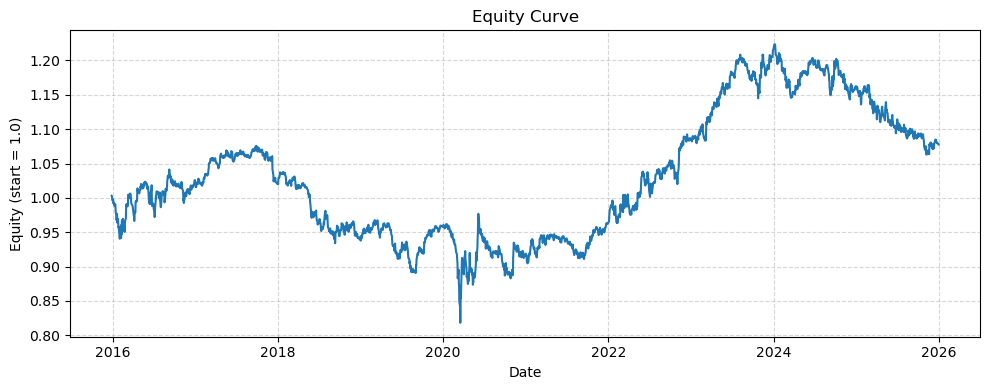

In [17]:
plot_equity_curve(daily_pnl0,"Equity Curve")

## 2.1 Alpha 0617a

In [18]:
alpha_pv1 = alpha_0617a(open_df,volume_df)

In [19]:
factor, fwd, ic = factor_forward_returns_wide(alpha_pv1, close_df, periods=(1,5,10))

/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_94249/2569342948.py:18: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = prices.pct_change(p).shift(-p)
/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_94249/2569342948.py:18: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = prices.pct_change(p).shift(-p)
/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_94249/2569342948.py:18: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling

In [20]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel = alpha_pv1
alpha_panel = alpha_panel.iloc[:-1, :]
fwd_ret     = fwd_ret.iloc[:-1, :]

# Apply weights and compute pnl
weights = alpha_panel.apply(make_weights, axis=1)  # same shape as alpha_panel
daily_pnl = (weights * fwd_ret).sum(axis=1)

In [21]:
performance_summary(daily_pnl,252)

===== Performance Summary =====
Periods             : 2228
Total Return        :   34.54%
CAGR                :    3.41%
Ann. Volatility     :    4.44%
Sharpe Ratio        :     0.77
Max Drawdown        :   -5.15%
Calmar Ratio        :     0.66
Hit Rate (p>0)      :   52.33%


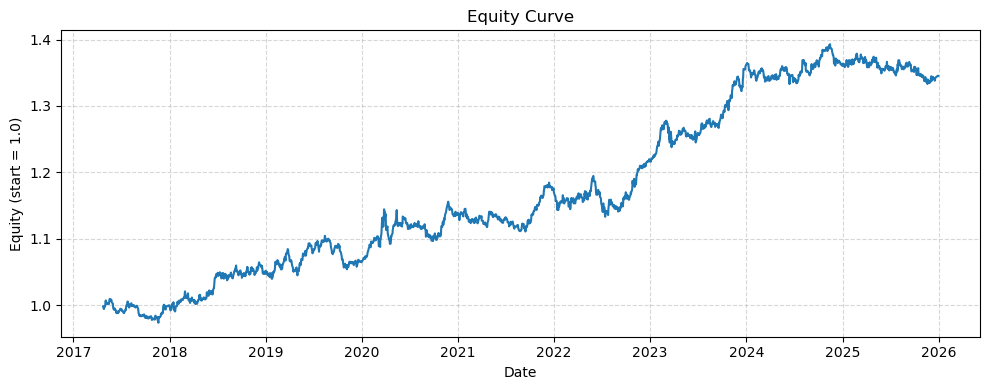

In [22]:
plot_equity_curve(daily_pnl,"Equity Curve")

## 2.2 Alpha 0810a

In [23]:
alpha2 = alpha_0810a(returns_df,cap_df,volume_df)

In [24]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel2 = alpha2
alpha_panel2 = alpha_panel2.iloc[:-1, :]

# Apply weights and compute pnl
weights2 = alpha_panel2.apply(make_weights, axis=1)
daily_pnl2 = (weights2 * fwd_ret).sum(axis=1)

In [25]:
performance_summary(daily_pnl2,252)

===== Performance Summary =====
Periods             : 2467
Total Return        :   24.71%
CAGR                :    2.28%
Ann. Volatility     :    4.28%
Sharpe Ratio        :     0.53
Max Drawdown        :   -7.42%
Calmar Ratio        :     0.31
Hit Rate (p>0)      :   52.45%


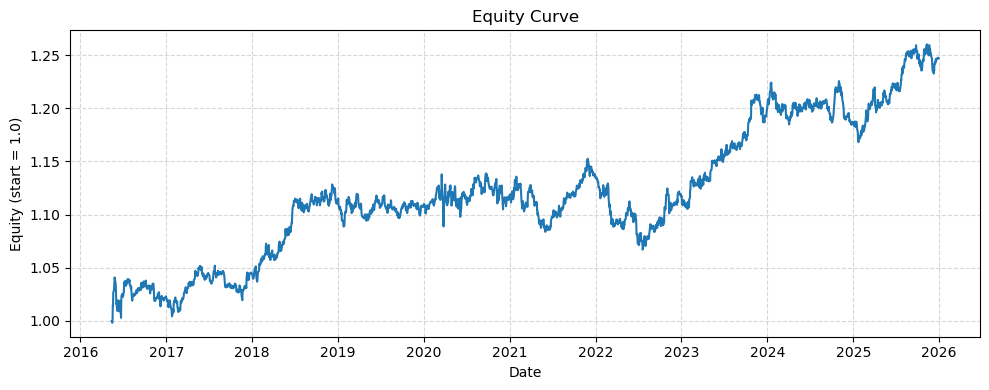

In [26]:
plot_equity_curve(daily_pnl2,"Equity Curve")

## 2.3 Alpha 0415b

In [27]:
alpha3 = alpha_0415b(close_df,volume_df)

In [28]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel3 = alpha3
alpha_panel3 = alpha_panel3.iloc[:-1, :]

# Apply weights and compute pnl
weights3 = alpha_panel3.apply(make_weights, axis=1)
daily_pnl3 = (weights3 * fwd_ret).sum(axis=1)

In [29]:
performance_summary(daily_pnl3,252)

===== Performance Summary =====
Periods             : 2224
Total Return        :   36.05%
CAGR                :    3.55%
Ann. Volatility     :    4.65%
Sharpe Ratio        :     0.76
Max Drawdown        :  -12.70%
Calmar Ratio        :     0.28
Hit Rate (p>0)      :   53.15%


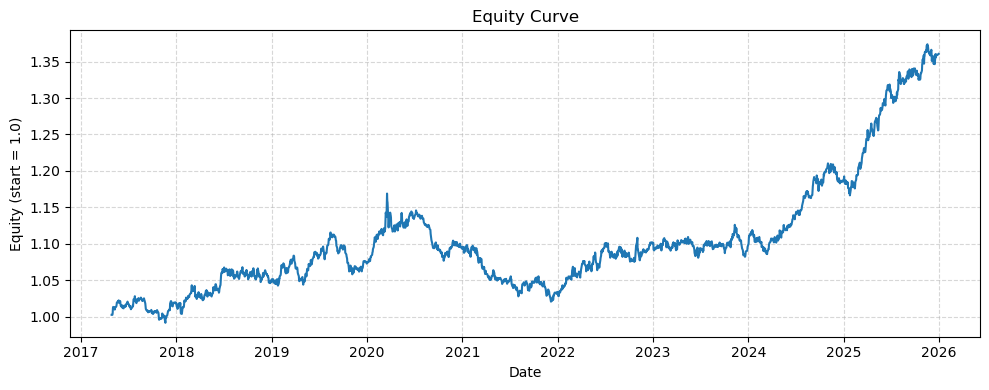

In [30]:
plot_equity_curve(daily_pnl3,"Equity Curve")

## 2.4 Alpha 0616a

In [31]:
alpha4 = alpha_0616a(close_df,open_df,volume_df)

In [32]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel4 = alpha4
alpha_panel4 = alpha_panel4.iloc[:-1, :]

# Apply weights and compute pnl
weights4 = alpha_panel4.apply(make_weights, axis=1)
daily_pnl4 = (weights4 * fwd_ret).sum(axis=1)

In [33]:
performance_summary(daily_pnl4,252)

===== Performance Summary =====
Periods             : 2224
Total Return        :   21.59%
CAGR                :    2.24%
Ann. Volatility     :    4.40%
Sharpe Ratio        :     0.51
Max Drawdown        :   -8.21%
Calmar Ratio        :     0.27
Hit Rate (p>0)      :   51.44%


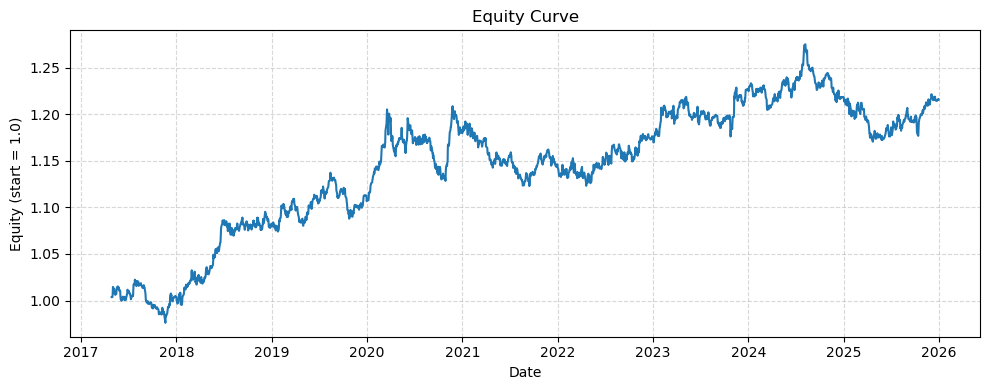

In [34]:
plot_equity_curve(daily_pnl4,"Equity Curve")

## 2.5 Alpha0812a

In [35]:
alpha5 = alpha_0812a(liabilities_df,assets_df,debt_df,equity_df)

In [36]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel5 = alpha5
alpha_panel5 = alpha_panel5.iloc[:-1, :]

# Apply weights and compute pnl
weights5 = alpha_panel5.apply(make_weights, axis=1)
daily_pnl5 = (weights5 * fwd_ret).sum(axis=1)

In [37]:
performance_summary(daily_pnl5,252)

===== Performance Summary =====
Periods             : 2313
Total Return        :   31.50%
CAGR                :    3.03%
Ann. Volatility     :    4.43%
Sharpe Ratio        :     0.68
Max Drawdown        :   -8.30%
Calmar Ratio        :     0.37
Hit Rate (p>0)      :   51.36%


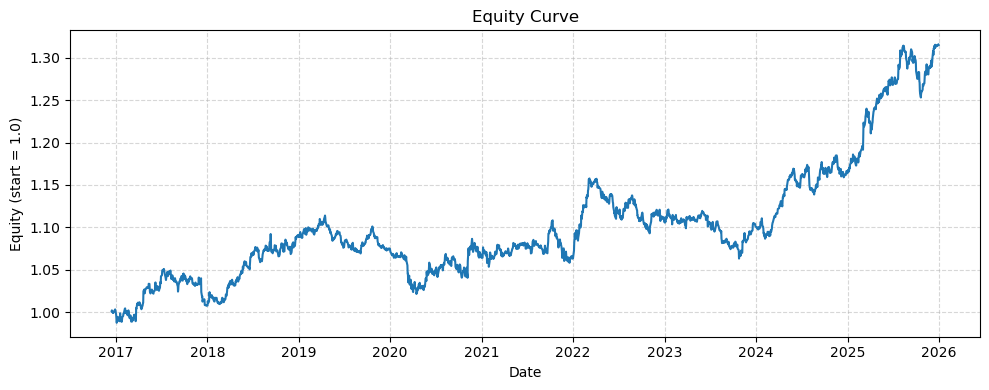

In [38]:
plot_equity_curve(daily_pnl5,'Equity Curve')

## 2.6 Alpha0612d

In [39]:
alpha6 = alpha_0612d(debt_df,assets_df,volume_df)

/Users/apple/Documents/GitHub/Quant/notebooks/operators_library.py:140: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cond = cond_df.reindex(val_df.index).fillna(False).astype(bool)


In [40]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel6 = alpha6
alpha_panel6 = alpha_panel6.iloc[:-1, :]

# Apply weights and compute pnl
weights6 = alpha_panel6.apply(make_weights, axis=1)
daily_pnl6 = (weights6 * fwd_ret).sum(axis=1)

In [41]:
performance_summary(daily_pnl6,252)

===== Performance Summary =====
Periods             : 2079
Total Return        :   40.75%
CAGR                :    4.23%
Ann. Volatility     :    8.82%
Sharpe Ratio        :     0.48
Max Drawdown        :  -19.92%
Calmar Ratio        :     0.21
Hit Rate (p>0)      :   42.23%


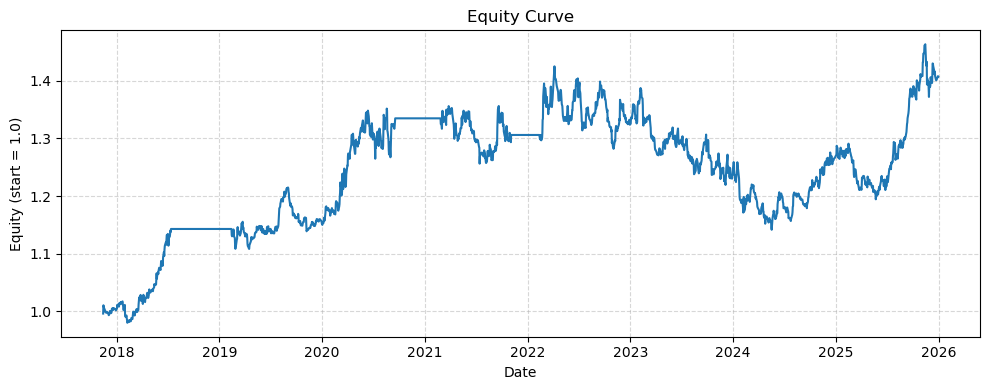

In [42]:
plot_equity_curve(daily_pnl6,"Equity Curve")

## 2.7 Alpha 0608d

In [43]:
alpha7 = alpha_0608d(close_df,open_df,volume_df,sharesout_df,industries,horro_window=10)

In [44]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel7 = alpha7
alpha_panel7 = alpha_panel7.iloc[:-1, :]

# Apply weights and compute pnl
weights7 = alpha_panel7.apply(make_weights, axis=1)
daily_pnl7 = (weights7 * fwd_ret).sum(axis=1)

In [45]:
performance_summary(daily_pnl7,252)

===== Performance Summary =====
Periods             : 2469
Total Return        :   42.97%
CAGR                :    3.72%
Ann. Volatility     :    7.67%
Sharpe Ratio        :     0.48
Max Drawdown        :  -15.57%
Calmar Ratio        :     0.24
Hit Rate (p>0)      :   50.63%


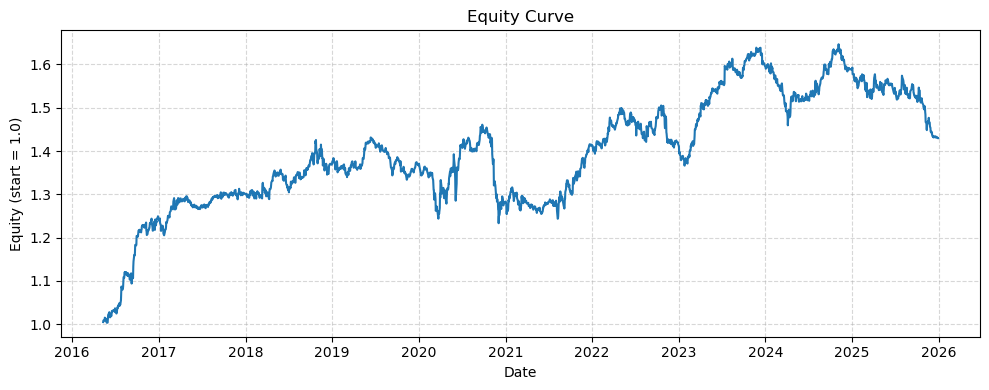

In [46]:
plot_equity_curve(daily_pnl7,"Equity Curve")

## 2.8 Alpha0615a

In [47]:
alpha8 = alpha_0615a(volume_df,sharesout_df,cap_df)

In [48]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel8 = alpha8
alpha_panel8 = alpha_panel8.iloc[:-1, :]

# Apply weights and compute pnl
weights8 = alpha_panel8.apply(make_weights, axis=1)
daily_pnl8 = (weights8 * fwd_ret).sum(axis=1)

In [49]:
performance_summary(daily_pnl8,252)

===== Performance Summary =====
Periods             : 1795
Total Return        :   26.94%
CAGR                :    3.41%
Ann. Volatility     :    4.35%
Sharpe Ratio        :     0.78
Max Drawdown        :   -6.72%
Calmar Ratio        :     0.51
Hit Rate (p>0)      :   50.97%


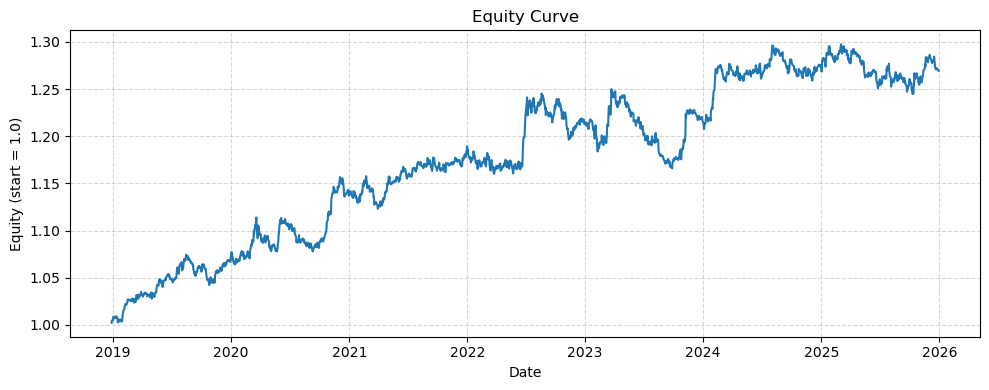

In [50]:
plot_equity_curve(daily_pnl8,"Equity Curve")

## 2.9 Alpha0604c

In [51]:
alpha9 = alpha_0604c(close_df,high_df,low_df)

In [52]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel9 = alpha9
alpha_panel9 = alpha_panel9.iloc[:-1, :]

# Apply weights and compute pnl
weights9 = alpha_panel9.apply(make_weights, axis=1)
daily_pnl9 = (weights9 * fwd_ret).sum(axis=1)

In [53]:
performance_summary(daily_pnl9,252)

===== Performance Summary =====
Periods             : 2707
Total Return        :   33.78%
CAGR                :    2.75%
Ann. Volatility     :    6.01%
Sharpe Ratio        :     0.46
Max Drawdown        :  -18.41%
Calmar Ratio        :     0.15
Hit Rate (p>0)      :   51.57%


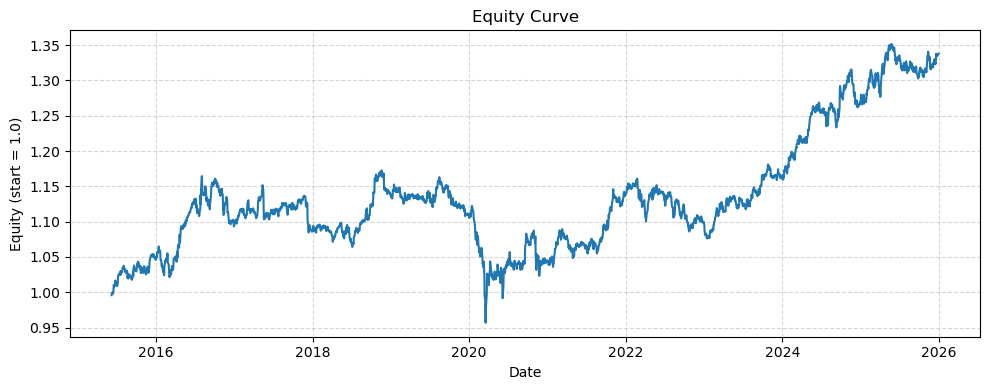

In [54]:
plot_equity_curve(daily_pnl9,"Equity Curve")

## 2.10 Alpha0407a

In [55]:
alpha10 = alpha_0407a(debt_df)

In [56]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel10 = alpha10
alpha_panel10 = alpha_panel10.iloc[:-1, :]

# Apply weights and compute pnl
weights10 = alpha_panel10.apply(make_weights, axis=1)
daily_pnl10 = (weights10 * fwd_ret).sum(axis=1)

In [57]:
performance_summary(daily_pnl10,252)

===== Performance Summary =====
Periods             : 2786
Total Return        :  186.13%
CAGR                :    9.98%
Ann. Volatility     :   14.36%
Sharpe Ratio        :     0.69
Max Drawdown        :  -21.41%
Calmar Ratio        :     0.47
Hit Rate (p>0)      :   52.69%


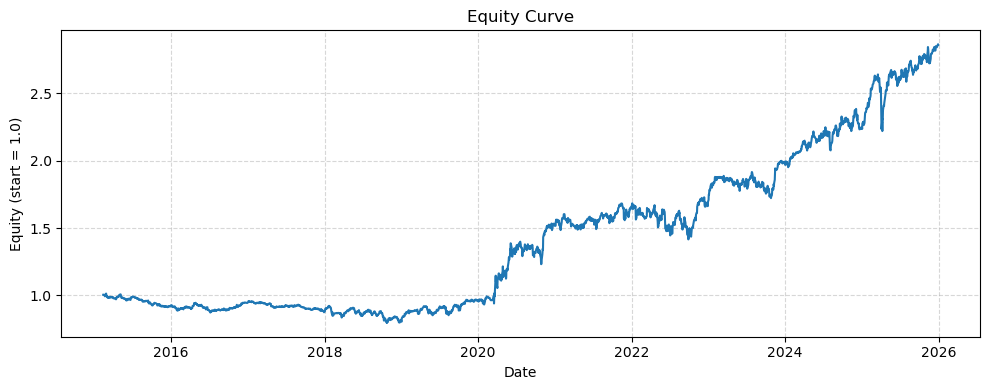

In [58]:
plot_equity_curve(daily_pnl10,"Equity Curve")

## 2.11 Alpha0505

In [59]:
alpha11 = alpha_0505(operating_income_df,vwap_df)

In [60]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel11 = alpha11
alpha_panel11 = alpha_panel11.iloc[:-1, :]

# Apply weights and compute pnl
weights11 = alpha_panel11.apply(make_weights, axis=1)
daily_pnl11 = (weights11 * fwd_ret).sum(axis=1)

In [61]:
performance_summary(daily_pnl11,252)

===== Performance Summary =====
Periods             : 2325
Total Return        :   24.89%
CAGR                :    2.44%
Ann. Volatility     :    7.45%
Sharpe Ratio        :     0.33
Max Drawdown        :  -20.63%
Calmar Ratio        :     0.12
Hit Rate (p>0)      :   34.37%


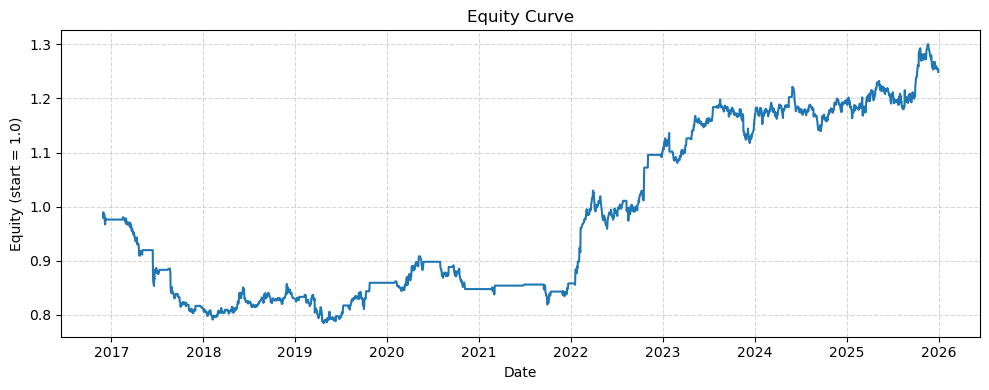

In [62]:
plot_equity_curve(daily_pnl11,"Equity Curve")

## 2.12 Alpha0413a

In [63]:
alpha12 = alpha_0413a(close_df,high_df,low_df)

In [64]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel12 = alpha12
alpha_panel12 = alpha_panel12.iloc[:-1, :]

# Apply weights and compute pnl
weights12 = alpha_panel12.apply(make_weights, axis=1)
daily_pnl12 = (weights12 * fwd_ret).sum(axis=1)

In [65]:
performance_summary(daily_pnl12,252)

===== Performance Summary =====
Periods             : 2816
Total Return        :   -5.89%
CAGR                :   -0.54%
Ann. Volatility     :    5.25%
Sharpe Ratio        :    -0.10
Max Drawdown        :  -20.12%
Calmar Ratio        :    -0.03
Hit Rate (p>0)      :   50.53%


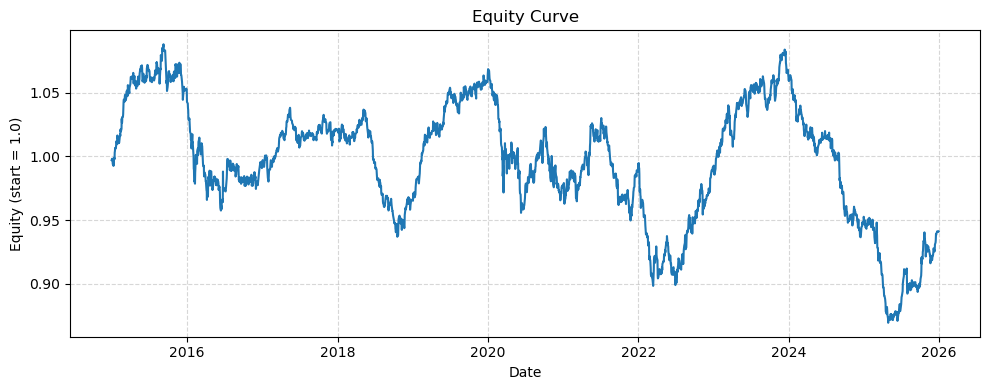

In [66]:
plot_equity_curve(daily_pnl12,"Equity Curve")

## 2.13 Alpha0413b

In [67]:
alpha13 = alpha_0413b(operating_income_df,cap_df)

In [68]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel13 = alpha13
alpha_panel13 = alpha_panel13.iloc[:-1, :]

# Apply weights and compute pnl
weights13 = alpha_panel13.apply(make_weights, axis=1)
daily_pnl13 = (weights13 * fwd_ret).sum(axis=1)

In [69]:
performance_summary(daily_pnl13,252)

===== Performance Summary =====
Periods             : 2746
Total Return        :   44.05%
CAGR                :    3.41%
Ann. Volatility     :    6.57%
Sharpe Ratio        :     0.52
Max Drawdown        :  -16.98%
Calmar Ratio        :     0.20
Hit Rate (p>0)      :   51.68%


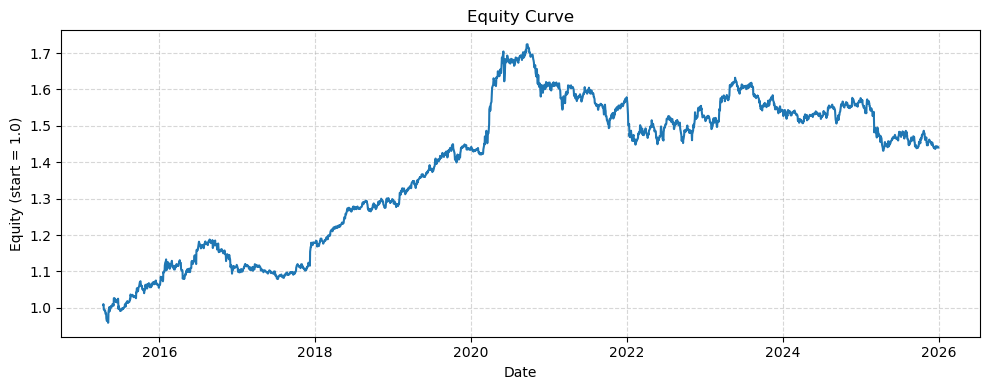

In [70]:
plot_equity_curve(daily_pnl13,"Equity Curve")

## 2.14 Alpha0503b

In [71]:
alpha14 = alpha_0503b(sharesout_df,volume_df,vwap_df,low_df,open_df,high_df)

In [72]:
alpha14.head()

,ABI.BR,AD.AS,ADSGn.DE,ADYEN.AS,AIR.PA,AIRP.PA,ALVG.DE,ARGX.BR,ASML.AS,AXAF.PA,...,SAN.MC,SAPG.DE,SASY.PA,SCHN.PA,SGEF.PA,SGOB.PA,SIEGn.DE,TTEF.PA,VOWG_p.DE,WLSNc.AS
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-30,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2015-01-01,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2015-01-02,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2015-01-05,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2015-01-06,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [73]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel14 = alpha14
alpha_panel14 = alpha_panel14.iloc[:-1, :]

# Apply weights and compute pnl
weights14 = alpha_panel14.apply(make_weights, axis=1)
daily_pnl14 = ((weights14 * fwd_ret).sum(axis=1).fillna(0.0))

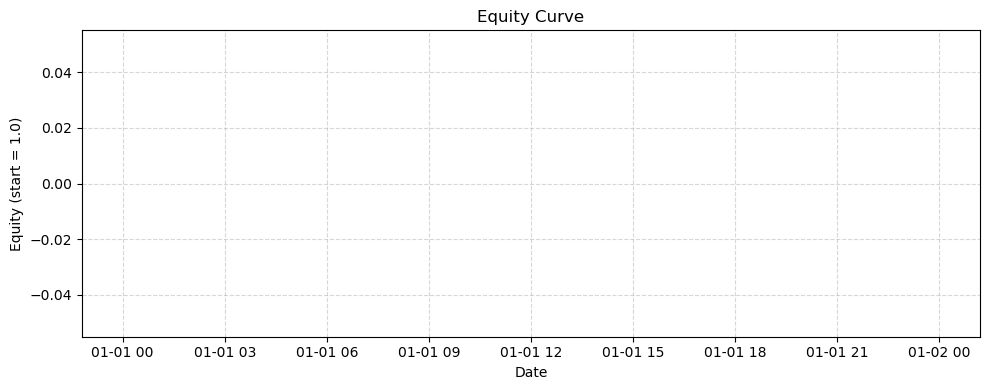

In [74]:
plot_equity_curve(daily_pnl14,"Equity Curve")

## 2.15 Alpha0603a

In [75]:
alpha15 = alpha_0603a(volume_df,sharesout_df,cap_df)

In [76]:
# Backtest
# align shapes: drop last row (no forward return)
alpha_panel15 = alpha15
alpha_panel15 = alpha_panel15.iloc[:-1, :]

# Apply weights and compute pnl
weights15 = alpha_panel15.apply(make_weights, axis=1)
daily_pnl15 = ((weights15 * fwd_ret).sum(axis=1).fillna(0.0))

In [77]:
performance_summary(daily_pnl15,252)

===== Performance Summary =====
Periods             : 1795
Total Return        :   29.33%
CAGR                :    3.68%
Ann. Volatility     :    4.89%
Sharpe Ratio        :     0.75
Max Drawdown        :   -6.91%
Calmar Ratio        :     0.53
Hit Rate (p>0)      :   50.19%


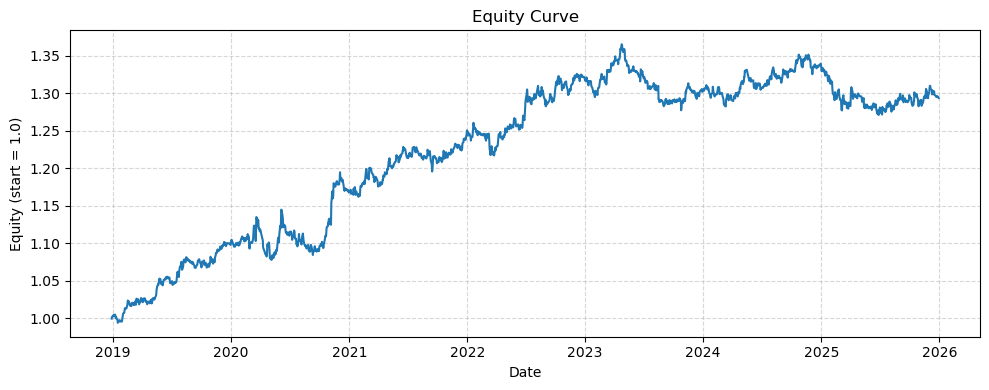

In [78]:
plot_equity_curve(daily_pnl15,'Equity Curve')

## 2.16 Alpha0416a

In [79]:
alpha16 = alpha_0416a(returns_df,subindustries,volume_df)

In [80]:
alpha_panel16 = alpha16
alpha_panel16 = alpha_panel16.iloc[:-1, :]

# Apply weights and compute pnl
weights16 = alpha_panel16.apply(make_weights, axis=1)
daily_pnl16 = ((weights16 * fwd_ret).sum(axis=1).fillna(0.0))

In [81]:
performance_summary(daily_pnl16,252)

===== Performance Summary =====
Periods             : 2608
Total Return        :   -7.83%
CAGR                :   -0.78%
Ann. Volatility     :    5.94%
Sharpe Ratio        :    -0.13
Max Drawdown        :  -27.80%
Calmar Ratio        :    -0.03
Hit Rate (p>0)      :   49.73%


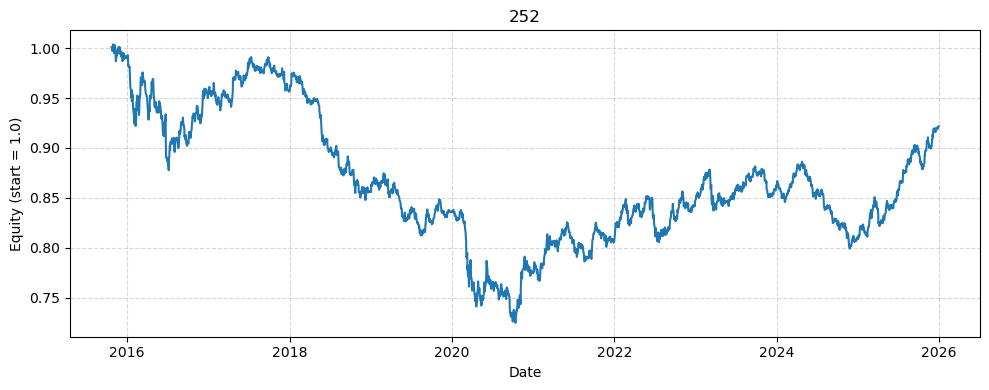

In [82]:
plot_equity_curve(daily_pnl16,252)

## 2.17 Alpha0421b

In [87]:
alpha17 = alpha_0421b(close_df,open_df,volume_df,returns_df)

TypeError: boolean value of NA is ambiguous